# Key Performance Indicators (KPIs)

## Objective

This notebook summarizes the key performance indicators (KPIs) derived from the exploratory data analysis of the European Banking Customer Churn dataset. These KPIs provide concise business metrics for evaluating customer churn risk, identifying high-risk customer segments, and supporting strategic decision-making.

The results presented in this notebook serve as the foundation for the Streamlit dashboard and executive summary by translating analytical findings into measurable business indicators.

In [3]:
# Load Processed Dataset

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/processed/European_bank_cleaned.csv")

---
## A. Overall Churn Rate

The Overall Churn Rate represents the percentage of customers who have exited the bank. It serves as the primary performance indicator for measuring customer retention and provides a baseline for comparing churn across different customer segments.

In [4]:
# Calculate overall churn distribution

overall_churn = (
    df["Exited"]
    .value_counts(normalize=True)
    .mul(100)
    .rename(index={0: "Retained", 1: "Churned"})
    .reset_index()
)

overall_churn.columns = ["Customer Status", "Percentage"]

overall_churn

,Customer Status,Percentage
0,Retained,79.63
1,Churned,20.37


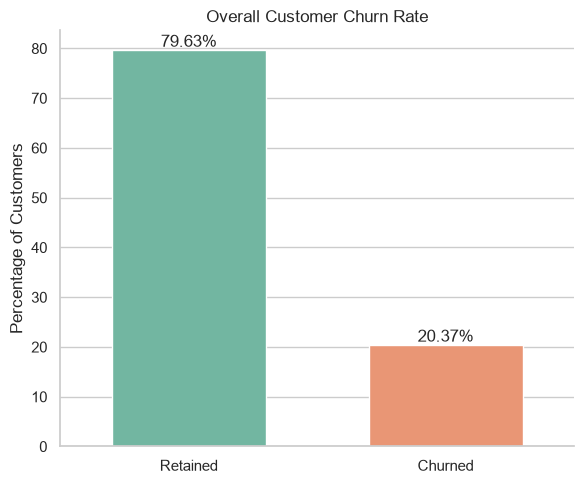

In [5]:
plt.figure(figsize=(6, 5))

ax = sns.barplot(
    data=overall_churn,
    x="Customer Status",
    y="Percentage",
    width=0.6,
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.title("Overall Customer Churn Rate")
plt.xlabel("")
plt.ylabel("Percentage of Customers")

sns.despine()
plt.tight_layout()
plt.show()

### Observation

- Out of all customers, **79.63%** were retained while **20.37%** exited the bank.
- Approximately one in every five customers has churned, indicating that customer retention remains a significant business challenge.
- The overall churn rate provides the baseline against which all subsequent segment-level churn analyses are compared.

### Business Insight

An overall churn rate of **20.37%** indicates that a considerable proportion of customers are leaving the bank. Reducing this baseline churn through targeted retention strategies, particularly among high-risk customer segments identified in previous analyses, can significantly improve long-term customer value and profitability.

---
## B. Segment Churn Rate

Segment Churn Rate measures the percentage of customers who exited within specific customer segments. Analysing churn across different demographic and financial categories helps identify high-risk customer groups and supports targeted retention strategies.

This section focuses on the three most influential segmentation dimensions identified during the exploratory data analysis:

- Geography
- Age Group
- Balance Category

### 1. Geography-wise Churn Rate

This KPI compares customer churn rates across different geographic regions to identify markets with the highest customer attrition.

In [8]:
geography_churn = (
    df.groupby("Geography")["Exited"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
      .reset_index()
)

geography_churn.columns = ["Geography", "Churn Rate (%)"]

geography_churn

,Geography,Churn Rate (%)
0,Germany,32.44
1,Spain,16.67
2,France,16.15


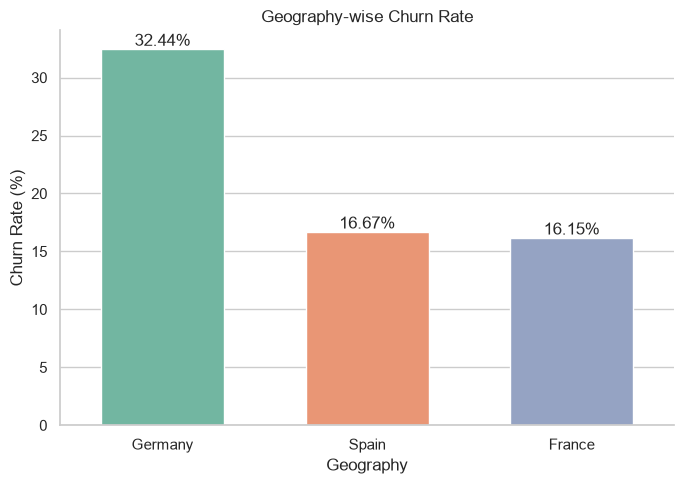

In [7]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=geography_churn,
    x="Geography",
    y="Churn Rate (%)",
    width=0.6,
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.title("Geography-wise Churn Rate")
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")

sns.despine()
plt.tight_layout()
plt.show()

#### Observation

- Germany records the highest churn rate at **32.44%**, which is approximately twice that of France and Spain.
- Spain and France have similar churn rates of **16.67%** and **16.15%**, respectively.
- The large variation across regions indicates that customer churn differs significantly by geography.

#### Business Insight

Germany represents the highest regional churn risk and should be prioritised for customer retention initiatives. Targeted marketing campaigns, personalised financial services, and improved customer engagement in this region could significantly reduce overall customer attrition.

### 2. Age Group Churn Rate

This KPI measures customer churn across different age groups to identify demographic segments with the highest risk of attrition. Understanding age-based churn patterns enables the bank to develop targeted retention strategies for different customer demographics.

In [9]:
age_churn = (
    df.groupby("AgeGroup")["Exited"]
      .mean()
      .mul(100)
      .round(2)
      .reindex(["Below 30", "30–45", "46–60", "Above 60"])
      .reset_index()
)

age_churn.columns = ["Age Group", "Churn Rate (%)"]

age_churn

,Age Group,Churn Rate (%)
0,Below 30,7.52
1,30–45,15.74
2,46–60,51.12
3,Above 60,24.78


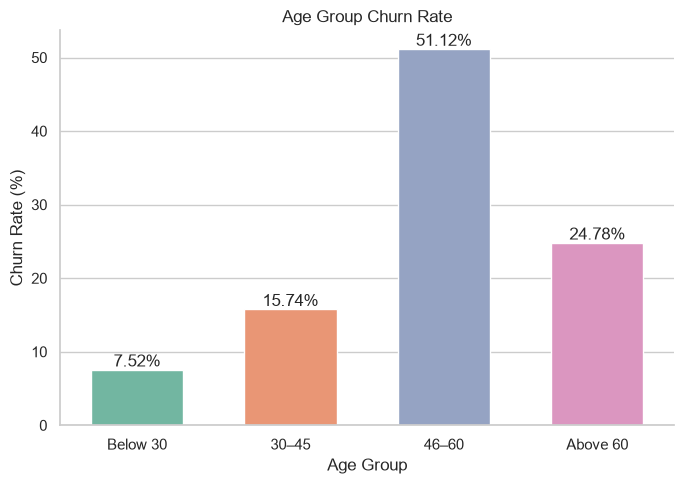

In [10]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=age_churn,
    x="Age Group",
    y="Churn Rate (%)",
    width=0.6,
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.title("Age Group Churn Rate")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")

sns.despine()
plt.tight_layout()
plt.show()

#### Observation

- Customers aged **46–60** have the highest churn rate at **51.12%**, meaning more than half of the customers in this age group have exited the bank.
- Customers **Above 60** have the second-highest churn rate at **24.78%**.
- The **30–45** age group records a churn rate of **15.74%**, while customers **Below 30** have the lowest churn rate at **7.52%**.
- The results indicate that customer churn generally increases with age, peaking in the 46–60 age group.

#### Business Insight

Customers aged **46–60** represent the highest demographic risk and should be prioritised for customer retention initiatives. Personalised financial products, proactive relationship management, and loyalty programmes targeting middle-aged customers can help reduce churn and improve long-term customer retention.

---
## C.High-Value Churn Ratio

The High-Value Churn Ratio measures the proportion of customers with high account balances who have exited the bank. Since high-balance customers contribute significantly to the bank's deposits and profitability, monitoring this KPI helps quantify the financial impact of customer churn and supports retention strategies for premium customers.

In [11]:
# High-value customers

high_value_customers = df[df["BalanceCategory"] == "High Balance"]

total_high_value = len(high_value_customers)

high_value_churners = high_value_customers["Exited"].sum()

high_value_churn_ratio = (
    high_value_churners / total_high_value
) * 100

kpi_high_value = pd.DataFrame({
    "Metric": [
        "Total High-Value Customers",
        "High-Value Customers Churned",
        "High-Value Churn Ratio (%)"
    ],
    "Value": [
        total_high_value,
        high_value_churners,
        round(high_value_churn_ratio, 2)
    ]
})

kpi_high_value

,Metric,Value
0,Total High-Value Customers,4799.00
1,High-Value Customers Churned,1211.00
2,High-Value Churn Ratio (%),25.23


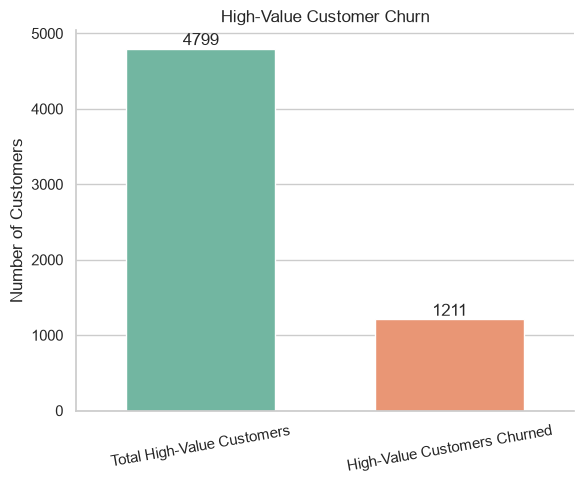

In [12]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=kpi_high_value.iloc[:2],
    x="Metric",
    y="Value",
    width=0.6,
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("High-Value Customer Churn")
plt.xlabel("")
plt.ylabel("Number of Customers")

plt.xticks(rotation=10)

sns.despine()
plt.tight_layout()
plt.show()

### Observation

- The dataset contains **4,799** high-value customers, of which **1,211** have exited the bank.
- This results in a **High-Value Churn Ratio of 25.23%**, indicating that approximately one in every four premium customers has churned.
- The churn of high-value customers represents a significant business concern due to their substantial contribution to the bank's total deposits and long-term profitability.

### Business Insight

A High-Value Churn Ratio of **25.23%** indicates that the bank is losing a considerable proportion of its premium customer base. Since these customers hold higher account balances, retaining them should be a strategic priority through personalised relationship management, exclusive banking services, loyalty programmes, and proactive customer engagement initiatives.

---
## D. Geographic Risk Index

The Geographic Risk Index ranks geographic regions based on their customer churn rates. It helps identify regional markets with the highest exposure to customer attrition, enabling the bank to prioritise retention efforts and allocate resources more effectively.

In [13]:
geographic_risk = (
    df.groupby("Geography")["Exited"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
      .reset_index()
)

geographic_risk.columns = ["Geography", "Risk Index (%)"]

geographic_risk

,Geography,Risk Index (%)
0,Germany,32.44
1,Spain,16.67
2,France,16.15


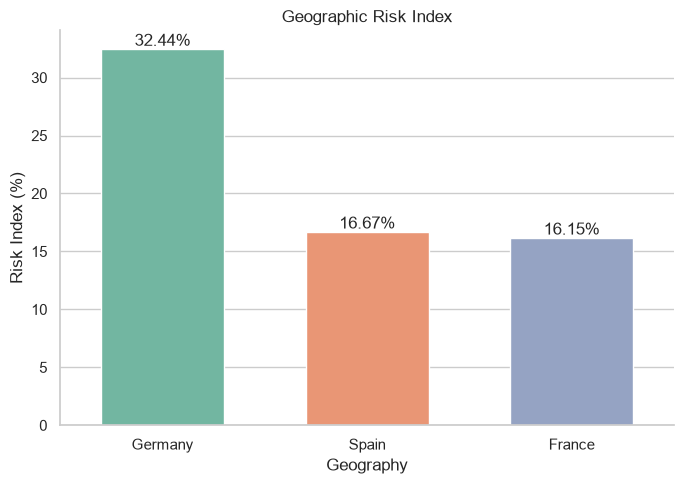

In [14]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=geographic_risk,
    x="Geography",
    y="Risk Index (%)",
    width=0.6,
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.title("Geographic Risk Index")
plt.xlabel("Geography")
plt.ylabel("Risk Index (%)")

sns.despine()
plt.tight_layout()
plt.show()

### Observation

- Germany has the highest Geographic Risk Index at **32.44%**, indicating the greatest exposure to customer churn.
- Spain (**16.67%**) and France (**16.15%**) have substantially lower and comparable churn rates.
- The regional variation suggests that geography is an important factor influencing customer retention.

### Business Insight

Germany represents the bank's highest-risk market and should be prioritised for customer retention initiatives. Implementing region-specific engagement strategies and improving customer experience in this market could significantly reduce overall churn and protect long-term business value.

---
## E. Engagement Drop Indicator

The Engagement Drop Indicator measures the relationship between customer activity status and churn. By comparing the churn rates of active and inactive customers, this KPI evaluates the impact of customer engagement on retention and identifies whether inactive customers are more likely to leave the bank.

In [16]:
engagement_kpi = (
    df.groupby("IsActiveMember")["Exited"]
      .mean()
      .mul(100)
      .round(2)
      .reset_index()
)

engagement_kpi["IsActiveMember"] = engagement_kpi["IsActiveMember"].map({
    0: "Inactive",
    1: "Active"
})

engagement_kpi.columns = ["Customer Status", "Churn Rate (%)"]

engagement_kpi

,Customer Status,Churn Rate (%)
0,Inactive,26.85
1,Active,14.27


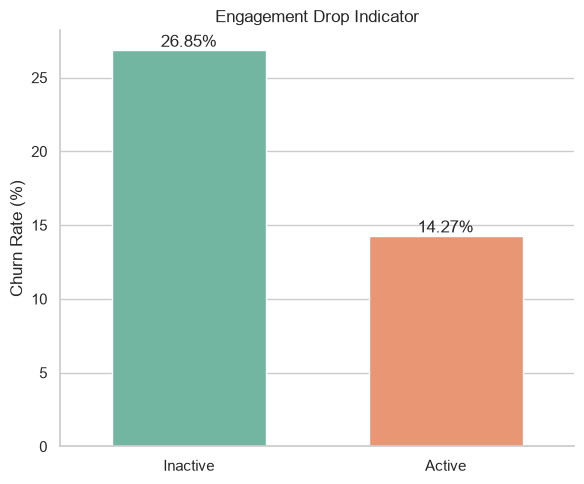

In [17]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=engagement_kpi,
    x="Customer Status",
    y="Churn Rate (%)",
    width=0.6,
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.title("Engagement Drop Indicator")
plt.xlabel("")
plt.ylabel("Churn Rate (%)")

sns.despine()
plt.tight_layout()
plt.show()

### Observation

- Inactive customers have a churn rate of **26.85%**, which is substantially higher than the **14.27%** churn rate observed among active customers.
- The churn rate for inactive customers is nearly twice that of active customers.
- These results indicate a strong relationship between customer engagement and customer retention.

### Business Insight

Customer engagement plays a significant role in reducing churn. Encouraging inactive customers to become more engaged through personalised communication, loyalty programmes, digital banking services, and targeted promotional campaigns can help improve customer retention and reduce overall churn.

---
## F. KPI Summary Dashboard

The following table summarises the key performance indicators derived from the customer churn analysis. These KPIs provide a concise overview of customer retention performance, high-risk customer segments, and business exposure to churn.

In [19]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Overall Churn Rate",
        "Highest Geographic Risk",
        "Highest Age Group Risk",
        "High-Value Churn Ratio",
        "Revenue at Risk",
        "Engagement Drop Indicator"
    ],
    "Value": [
        "20.37%",
        "Germany (32.44%)",
        "46–60 (51.12%)",
        "25.23%",
        "24.26%",
        "Inactive: 26.85% | Active: 14.27%"
    ]
})

kpi_summary

,KPI,Value
0,Overall Churn Rate,20.37%
1,Highest Geographic Risk,Germany (32.44%)
2,Highest Age Group Risk,46–60 (51.12%)
3,High-Value Churn Ratio,25.23%
4,Revenue at Risk,24.26%
5,Engagement Drop Indicator,Inactive: 26.85% | Active: 14.27%


## Summary

This notebook presented the key performance indicators (KPIs) derived from the customer churn analysis of the European Banking dataset. The results highlight the most significant business risks associated with customer attrition and identify the customer segments requiring immediate attention.

The overall customer churn rate is **20.37%**, with Germany exhibiting the highest regional churn risk (**32.44%**). Customers aged **46–60** represent the most vulnerable demographic, recording a churn rate of **51.12%**. Additionally, **25.23%** of high-value customers have exited the bank, placing a substantial proportion of customer deposits at risk. The analysis also shows that inactive customers (**26.85%**) are considerably more likely to churn than active customers (**14.27%**), emphasising the importance of customer engagement in improving retention.

These KPIs provide a concise overview of the bank's customer retention performance and will serve as the foundation for the Streamlit dashboard, research paper, executive summary, and strategic business recommendations.